# Seismic wave propagation in a floating ice sheet — Seismo-acoustic measurements

2026-02-20 · Cédric Schmelzbach (ETH Zurich), Christoph Wetter (WSL)

You will use this notebook to plot and analyze field data collected on Lake St. Moritz (Switzerland) during winter 2022. You will compare measurements of a three-component seismometer recordings from a LE-3D/5s MkIII sensor placed on the ice surface with the measurements of a microphone placed about 1 m above the seismometer.

Goals: identify the main wave modes and examine their characteristics in the time and time-frequency domain.

Reference to data and analyses:
Schmelzbach, C., C. Wetter and S. Stähler (2025), The sound of ice: characterising lake ice using
seismo-acoustic observations, Near Surface Geoscience Conference & Exhibition 2025. 10.3997/2214-
4609.202520265.

In [1]:
import os
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy.signal.rotate import rotate_ne_rt
from obspy import UTCDateTime
from scipy.signal import butter, filtfilt
from obspy import read, read_inventory
from obspy.signal.tf_misfit import cwt

# 1 - Comparison of seismic and seismo-acoustic observations

Overview
In this notebook, you will compare colocated seismometer and microphone recordings from Lake St. Moritz (winter 2022).

Instruments: a three‑component seismometer (LE‑3D/5s MkIII) on the ice surface and a microphone ≈1 m above the seismometer.

We analyse how ice‑coupled wave modes (i.e., $QS_0$, $QS$) couple into the air and how this coupling appears in time and time–frequency representations.

Run the cell to plot the microphone and three-component seismometer data with the same time axis. The seismometer data (same as used in the first notebook) are rotated to Z-R-T (back-azimuth of 41°).

Objectives
* Identify the main wave modes on the seismometer traces and microphone recording.
* Compare the microphone spectrogram with the seismometer spectrogram to detect air‑coupled waves (ACW) and the coincidence frequency.

Observations
The main arrivals on the seismometer recordings are marked:
- $QS_O$: fundamental-mode symmetric quasi‑Lamb wave
- $SH$: horizontally polarized shear wave
- $QS$: quasi‑Scholte wave

Note that in the microphone recording, energy above the background noise level is recorded from around 60.15 to 60.73 seconds. The $QS$ wave and a hardly visible $QS_0$ mode couple from the ice into the air. The air-coupled wave train is most prominent for the $QS$ wave and stops abruptly at around 60.73 seconds. At this time, the sound wave propagating from the source entirley in the air to the microphone reached the recording position.

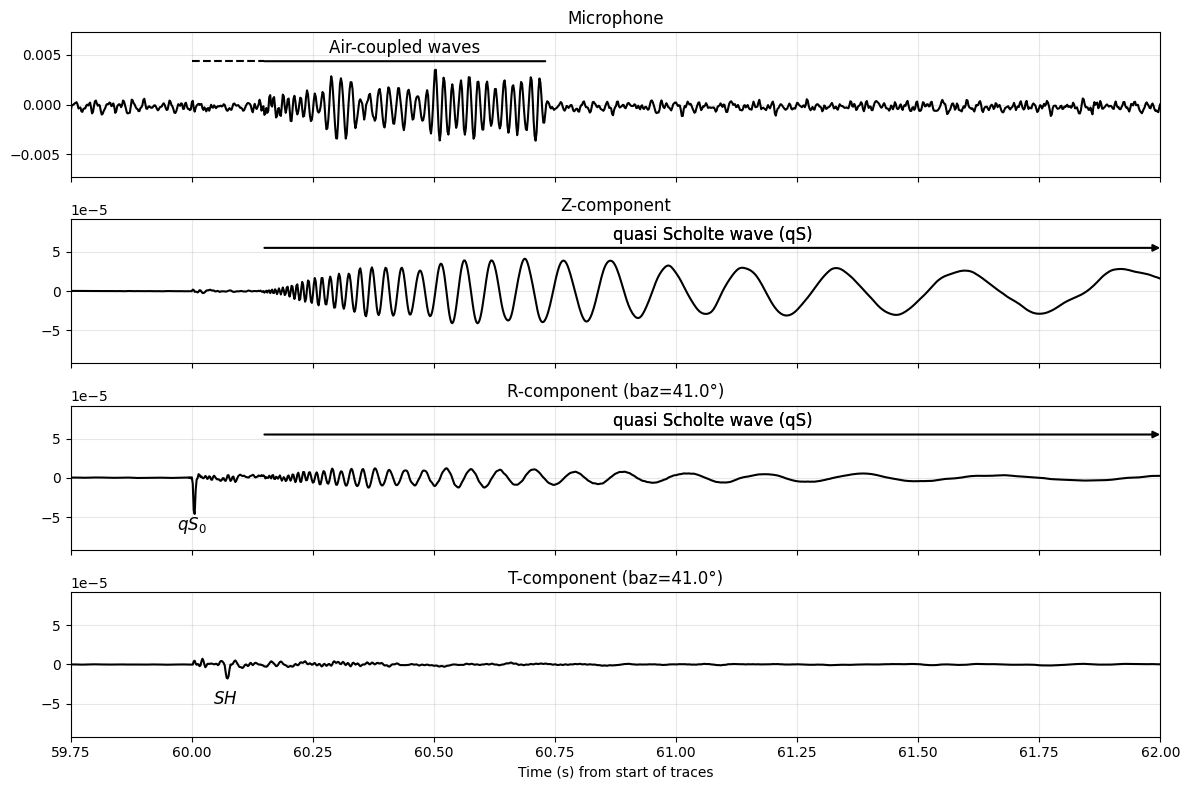

In [2]:
# Plot the seismometer and microphone data, zoom one one event

# --- No need to make changes below this line for the user ---
tr_eis10_z = obspy.read('LakeIceExample_CW_EIS10_Z.mseed')
tr_eis10_n = obspy.read('LakeIceExample_CW_EIS10_N.mseed')
tr_eis10_e = obspy.read('LakeIceExample_CW_EIS10_E.mseed')

# Microphone
tr_mic = obspy.read('LakeIceExample_CW_EIS10_Microphone.mseed')

# Set the time window to display (e.g., around the qS0 arrival at ~60s)
window_start_time = 59.75 # in seconds from start of traces
window_end_time = 62.0

# Set the back-azimuth for rotation (degrees)
baz = 41

r, t = rotate_ne_rt(tr_eis10_n[0].data, tr_eis10_e[0].data, baz)
trR = tr_eis10_z.copy(); trT = tr_eis10_z.copy()
trR[0].data = r
trT[0].data = t

# compute global max absolute amplitude across Z, R, T and set symmetric y-limits
all_amps = np.concatenate((np.abs(tr_eis10_z[0].data), np.abs(trR[0].data), np.abs(trT[0].data)))
max_amp = np.max(all_amps) if all_amps.size > 0 else 0.0
ylim = 2.0 * max_amp

# Scaling for microphone plot (optional, adjust as needed)
mic_max_amp = np.max(np.abs(tr_mic[0].data)) if tr_mic[0].data.size > 0 else 0.0
ylim_mic = 2.0 * mic_max_amp

fig, axs = plt.subplots(4,1, sharex=True, figsize=(12,8))
axs[0].plot(tr_mic[0].times(), tr_mic[0].data, 'k-'); axs[0].set_title('Microphone')
axs[0].grid(True, alpha=0.3)
axs[0].set_ylim(-ylim_mic, ylim_mic)
axs[1].plot(tr_eis10_z[0].times(), tr_eis10_z[0].data, 'k-'); axs[1].set_title('Z-component')
axs[2].plot(trR[0].times(), trR[0].data, 'k-'); axs[2].set_title(f'R-component (baz={baz:.1f}°)')
axs[3].plot(trT[0].times(), trT[0].data, 'k-'); axs[3].set_title(f'T-component (baz={baz:.1f}°)')
for ax in axs[1:]:
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(window_start_time, window_end_time)  # adjust x-limits to zoom in on the interesting part (e.g., around qS arrival)
axs[-1].set_xlabel('Time (s) from start of traces')


# Mark the air-coupled waves with a line and label
time_start_qs0 = 60.0       # start time of qS0 arrival (s) - adjust as needed based on the plot
x0_mic = 0.15 + time_start_qs0          # start time (s)
length_mic = np.min([0.58, window_end_time - 60 - 0.15]) # arrow length (s)
ylim_mic = 0.8                     # 80% of axes height (axes coords)
axs[0].annotate(
        '',
        xy=(x0_mic + length_mic, ylim_mic),
        xytext=(x0_mic, ylim_mic),
        xycoords=axs[0].get_xaxis_transform(),            # x in data, y in axes (0..1)
        arrowprops=dict(arrowstyle='-', color='k', lw=1.5, shrinkA=0, shrinkB=0),
        clip_on=False
)
# dashed horizontal line (same start x0, length, and height y in axes coordinates)
axs[0].plot([x0_mic-0.15, x0_mic], [ylim_mic, ylim_mic],
    transform=axs[0].get_xaxis_transform(),
    linestyle='--', color='k', linewidth=1.5, clip_on=False)

# Draw a horizontal arrow of given length (seconds) starting at x0 at NN% height
time_start_qs0 = 60.0       # start time of qS0 arrival (s) - adjust as needed based on the plot
x0 = 0.15 + time_start_qs0          # start time (s)
length = np.min([3.5, window_end_time - 60 - 0.15]) # arrow length (s)
y = 0.8                     # 80% of axes height (axes coords)

# ensure axs is indexable
arr = axs if isinstance(axs, (list, tuple, np.ndarray)) else [axs]

for ax in (arr[1], arr[2]):
    ax.annotate(
        '',
        xy=(x0 + length, y),
        xytext=(x0, y),
        xycoords=ax.get_xaxis_transform(),            # x in data, y in axes (0..1)
        arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, shrinkA=0, shrinkB=0),
        clip_on=False
    )
    
# optional: add centered label on each arrow
arr[0].text(x0_mic + length_mic/2, ylim_mic + 0.03, 'Air-coupled waves', transform=arr[0].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')

arr[1].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (qS)', transform=arr[1].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
arr[1].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (qS)', transform=arr[1].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
arr[2].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (qS)', transform=arr[2].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
arr[2].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (qS)', transform=arr[2].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')

axs[2].text(0 + time_start_qs0, 0.1, r'$qS_0$', transform=axs[2].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
axs[3].text(0.07 + time_start_qs0, 0.2, r'$SH$', transform=axs[3].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')

plt.tight_layout()
plt.show()


# 2 - Spectral properties of the air-coupled waves

Compute spectrograms of the microphone and vertical‑component seismometer data for the selected event, then compare them to detect air‑coupled waves (ACW) and the coincidence frequency.

Tasks
* Run the cell below to compute spectrograms for the microphone and the vertical seismometer trace.
* Use the spectrograms to compare time–frequency behaviour: look for the dispersive qS curve and the air‑coupled wave.

Tasks
* Identify the $QS$ dispersive curve in both spectrograms at early times.
* Locate the onset and end of the ACW interval.
* Estimate the coincidence frequency.
* Note them down for the next notebook

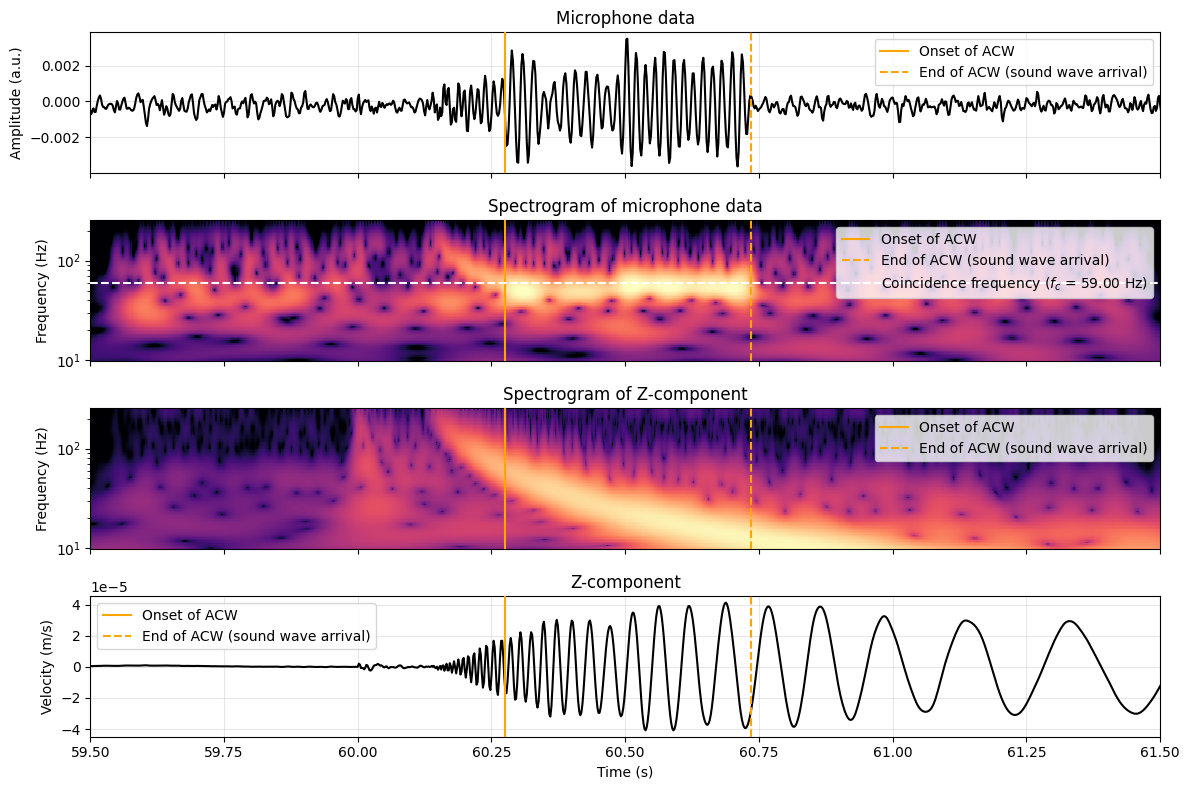

In [3]:
starttime_acw = 60.275 # Arrival time of ACW
endtime_acw = 60.735 # Arrival time of ACW

acw_fc = 59 # Coincidence frequency in Hz

# --- No need to make changes below this line for the user ---

# Trim for more focused time-frequency analysis around the qS0 arrival (e.g., 59-65s)
trace_start_time = 59.5
spectrogram_window = 2.0  # Set the time window duration for the spectrogram (e.g., 6 seconds to cover 59-65s)

# Extract start time
start_time = tr_eis10_z[0].stats.starttime

# Spectrogram of microphone data
tr_trim_mic = tr_mic.copy().trim(start_time + trace_start_time, start_time + trace_start_time + spectrogram_window)
tr_trim_mic.taper(max_percentage=0.05)
npts = tr_trim_mic[0].stats.npts
dt = tr_trim_mic[0].stats.delta
t = np.linspace(0, dt * npts, npts)
f_min = 10
f_max = 250
scalogram_mic = cwt(tr_trim_mic[0].data, dt, 5, f_min, f_max)
x_mic, y_mic = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram_mic.shape[0]))

# Spectrogram of seismic data
tr_trim = tr_eis10_z.copy().trim(start_time + trace_start_time, start_time + trace_start_time + spectrogram_window)
tr_trim.taper(max_percentage=0.05)
npts = tr_trim[0].stats.npts
dt = tr_trim[0].stats.delta
t = np.linspace(0, dt * npts, npts)
scalogram = cwt(tr_trim[0].data, dt, 5, f_min, f_max)
x, y = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram.shape[0]))

# Plotting
fig, axs = plt.subplots(4,1, sharex=True, figsize=(12,8),
                        gridspec_kw={'height_ratios':[1,1,1,1]})  # first axis half the height of second

# Microphone
axs[0].plot(tr_mic[0].times(), tr_mic[0].data, 'k-'); 
axs[0].set_title('Microphone data')
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(trace_start_time, trace_start_time + spectrogram_window)
axs[0].set_ylabel('Amplitude (a.u.)')
axs[0].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[0].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[0].legend()

im = axs[1].pcolormesh(x_mic + trace_start_time, y_mic, np.log10(np.abs(scalogram_mic)), cmap='magma', vmin=-6, vmax=-3.5)
axs[1].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[1].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[1].axhline(acw_fc, color='white', linestyle='--', linewidth=1.5, zorder=5, label=f'Coincidence frequency ($f_{{c}}$ = {acw_fc:.2f} Hz)')
axs[1].set_ylabel("Frequency (Hz)")
axs[1].set_yscale('log')
axs[1].set_title('Spectrogram of microphone data')
axs[1].legend()

# Z-component
axs[3].plot(tr_eis10_z[0].times(), tr_eis10_z[0].data, 'k-'); 
axs[3].set_title('Z-component')
axs[3].grid(True, alpha=0.3)
axs[3].set_xlim(trace_start_time, trace_start_time + spectrogram_window)
axs[3].set_ylabel('Velocity (m/s)')
axs[3].set_xlabel("Time (s)")
axs[3].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[3].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[3].legend()

im = axs[2].pcolormesh(x + trace_start_time, y, np.log10(np.abs(scalogram)), cmap='magma', vmin=-10, vmax=-5)
axs[2].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[2].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[2].set_ylabel("Frequency (Hz)")
axs[2].set_yscale('log')
axs[2].set_title('Spectrogram of Z-component')
axs[2].legend()

plt.tight_layout()
plt.show()